# Williams Alligator -- a quantitative teardown
### Real daily SPY - 13/8/5 SMMA fan - long/flat & long/short - HAC race vs B&H and SMA(200) - permutation placebo

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Catches_trends%3F: Not_supported](https://img.shields.io/badge/Catches_trends%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We compute the Alligator (three displaced SMMAs of the median price), turn the fan-out into a long/flat and a long/short timing rule, and race the **net Sharpe** against buy-and-hold and against the simplest trend benchmark (SMA(200)) on 33 years of SPY, with a HAC Sharpe-difference test, a circular-block permutation placebo, a cost sweep, and a synthetic faithful-engine control.

> **Not investment advice.** Real data: SPY daily total-return closes 1993-01-29 -> 2026-06-23 (n=8,406; fingerprint `6e7b9258f0b0`); cash leg proxied at 4%/yr flat (FRED unavailable); 5 bps one-way on NAV; short leg pays 50 bps/yr borrow. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_alligator import data, strategy as st

TICKER = "SPY"
SMA_N  = 200
TBILL  = 0.04 / 252.0   # flat 4%/yr daily proxy
COST   = 5.0             # one-way bps on NAV
BORROW = 50.0           # annual borrow on the short leg
END    = "2026-06-23"   # pin to last complete trading day

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-24).
R = dict(
    n=8406, start="1993-01-29", end="2026-06-23", fp="6e7b9258f0b0",
    in_pos_lf=59.1, n_changes_lf=497,
    bh_cagr=10.78, bh_sharpe=0.551, bh_vol=18.59, bh_dd=-55.19, bh_t=3.66,
    al_cagr=6.46, al_sharpe=0.593, al_vol=10.56, al_dd=-20.37, al_t=3.79,
    sma_cagr=9.12, sma_sharpe=0.726, sma_vol=12.01, sma_dd=-21.91, sma_t=4.50,
    t_allig_vs_bh=-1.71, t_allig_vs_sma=-1.61, placebo_p=0.151, placebo_obs=0.042,
    in_pos_ls=82.8, n_changes_ls=873,
    als_cagr=2.69, als_sharpe=0.156, als_vol=17.03, als_dd=-37.48, als_t=1.05,
    t_alligls_vs_bh=-1.85,
    sharpe_0bps=0.664, sharpe_1bps=0.650, sharpe_5bps=0.593,
    sharpe_10bps=0.522, sharpe_25bps=0.309,
    syn_null_bh=0.179, syn_null_al=0.357, syn_null_alt=1.44, syn_null_difft=0.42,
    syn_trend_bh=-0.130, syn_trend_al=1.999, syn_trend_alt=6.97, syn_trend_difft=4.75,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    bars   = data.load_real(TICKER).loc[:END]
    sig_lf = st.alligator_signal(bars, mode="long_flat")
    sig_sm = st.sma_signal(bars, n=SMA_N, mode="long_flat")
    bt_a   = st.run_backtest(bars, sig_lf, tbill_daily=TBILL, cost_bps=COST, borrow_bps_ann=BORROW)
    bt_s   = st.run_backtest(bars, sig_sm, tbill_daily=TBILL, cost_bps=COST, borrow_bps_ann=BORROW)
    s_bh   = st.summary(bt_a["r_bh"])
    s_al   = st.summary(bt_a["r_strategy"])
    s_sm   = st.summary(bt_s["r_strategy"])
    in_pos = float((sig_lf.abs() > 0).mean())
else:
    bars = None
    s_bh = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], max_drawdown=R["bh_dd"]/100, vol_ann=R["bh_vol"]/100)
    s_al = dict(cagr=R["al_cagr"]/100, sharpe=R["al_sharpe"], max_drawdown=R["al_dd"]/100, vol_ann=R["al_vol"]/100)
    s_sm = dict(cagr=R["sma_cagr"]/100, sharpe=R["sma_sharpe"], max_drawdown=R["sma_dd"]/100, vol_ann=R["sma_vol"]/100)
    in_pos = R["in_pos_lf"]/100
    bt_a = bt_s = sig_lf = None


real SPY cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Alligator long/flat Sharpe **0.593** vs B&H **0.551**, but the Sharpe-difference HAC *t* is **-1.71** (below |2|, and negative on the mean); permutation placebo *p* = **0.15**. Long/short is worse (Sharpe 0.156, diff-*t* -1.85). |
| **Tradability** | `MIRAGE` | Net CAGR **+6.5%** *lags* B&H **+10.8%**; strictly dominated by SMA(200) (Sharpe 0.726, diff-*t* -1.61). 497 position changes over 33y. |
| **Catches trends?** | `NOT SUPPORTED` | The only real effect is vol compression (10.6% vs 18.6%) and DD reduction (-20.4% vs -55.2%) -- shared by every slow trend filter and done *better* by one moving average. |

> in plain words: the Alligator is a vol-reducing crash filter that under-performs the single dumbest trend rule. Its higher-than-B&H Sharpe is a volatility artefact, not timing skill, and it does not clear the inference bar. The 'wake and eat' trend-catching story is not what 33 years of SPY shows.

## 1 -- The claim, formalised

Let $M_t = (H_t + L_t)/2$ be the median price and $\text{SMMA}_p$ the smoothed (Wilder, $\alpha = 1/p$) moving average. The three displaced lines are

$$\text{Jaw}_t = \text{SMMA}_{13}(M)_{t-8}, \quad \text{Teeth}_t = \text{SMMA}_{8}(M)_{t-5}, \quad \text{Lips}_t = \text{SMMA}_{5}(M)_{t-3}.$$

The position is $w_t = \mathbf{1}[\text{Lips}>\text{Teeth}>\text{Jaw}]_{t-1}$ (long/flat) or $\pm 1$ with the bearish fan adding the short leg (long/short). Strategy return $r_t^{\text{strat}} = w_t r_t^{\text{SPY}} + (1-|w_t|) r_t^{\text{cash}} - c\,|\Delta w_t| - b\,\mathbf{1}[w_t<0]$. The hypotheses:

- **H1 (beats B&H).** $\text{SR}(w) > \text{SR}(\text{BH})$ with the return-difference HAC |*t*| $\geq$ 2. **Rejected** (*t* = -1.71).
- **H2 (beats the simplest trend rule).** $\text{SR}(w) > \text{SR}(\text{SMA}_{200})$. **Rejected** -- SMA(200) is *higher* (*t* = -1.61).
- **H3 (it's timing, not luck).** Real signal beats a block-shuffle of itself. **Rejected** -- placebo *p* = 0.15.

## 2 -- So what? -- what rides on each answer

The Alligator is the flagship of Bill Williams' *Trading Chaos* school and one of the most-plotted indicators on retail platforms. If H1/H2 held, it would validate the multi-timeframe-confirmation idea (fast/medium/slow averages agreeing). The honest decomposition we insist on -- *race the indicator against the dumbest member of its own family* -- is what separates 'beats buy-and-hold' (cheap, any de-risking rule does it) from 'adds timing information' (the actual claim). A rule that loses to SMA(200) cannot be selling timing skill; it is selling reduced exposure with extra steps.

## 3 -- How we'd know -- the protocol

- **Signal.** Three displaced SMMAs of the median price; fan-state lagged one day (signal at $t$ acts on return $t\to t+1$). The forward displacement only uses older data, so it is conservative -- no look-ahead.
- **Arms.** long/flat (cash when not bullish) and long/short (short the bearish fan).
- **Cash leg.** Flat 4%/yr (FRED unavailable). **Cost** 5 bps one-way on NAV, swept 0--25 bps. **Borrow** 50 bps/yr on the short leg.
- **Benchmarks.** Buy-and-hold *and* SMA(200) through the identical engine.
- **Inference.** HAC (Newey-West) *t* on mean daily return and on the return-difference (Jobson-Korkie style) for each race; a circular-block (21-day) permutation placebo on the signal.
- **Positive control.** A synthetic tape with *planted* multi-week trends (symmetric up/down runs) to confirm the long/short engine catches trends when they exist, and adds nothing on an i.i.d. null.

## 4 -- The teardown

### 4a -- The three-way race with HAC inference

Same engine, same lag, same costs. The decisive columns are the two right-hand Sharpe-difference *t*-stats.

In [2]:
rows = [('Buy & hold', s_bh), ('Alligator L/F', s_al), ('SMA(200) L/F', s_sm)]
print(f'{"Arm":16s} | {"CAGR":>7s} | {"Sharpe":>7s} | {"Vol":>6s} | {"MaxDD":>7s} | {"HAC t":>6s}')
print('-'*64)
for lbl, s in rows:
    t = s.get('tstat', float('nan'))
    print(f'{lbl:16s} | {s["cagr"]:+6.2%} | {s["sharpe"]:+7.3f} | {s["vol_ann"]:5.1%} | {s["max_drawdown"]:+6.1%} | {t:+6.2f}')
if HAVE_REAL:
    t_bh  = st.sharpe_diff_tstat(bt_a['r_strategy'], bt_a['r_bh'])
    t_sma = st.sharpe_diff_tstat(bt_a['r_strategy'], bt_s['r_strategy'])
else:
    t_bh, t_sma = R['t_allig_vs_bh'], R['t_allig_vs_sma']
print(f'\nSharpe-diff t  Alligator vs Buy&hold:  {t_bh:+.2f}  (need |t|>=2 -> {abs(t_bh)>=2})')
print(f'Sharpe-diff t  Alligator vs SMA(200):  {t_sma:+.2f}  (SMA is the higher Sharpe)')


Arm              |    CAGR |  Sharpe |    Vol |   MaxDD |  HAC t
----------------------------------------------------------------
Buy & hold       | +10.78% |  +0.551 | 18.6% | -55.2% |  +3.66
Alligator L/F    | +6.46% |  +0.593 | 10.6% | -20.4% |  +3.79
SMA(200) L/F     | +9.12% |  +0.726 | 12.0% | -21.9% |  +4.50

Sharpe-diff t  Alligator vs Buy&hold:  -1.71  (need |t|>=2 -> False)
Sharpe-diff t  Alligator vs SMA(200):  -1.61  (SMA is the higher Sharpe)


> in plain words: the Alligator's Sharpe is a touch above buy-and-hold but the difference is *not* statistically real (and the mean return is actually lower -- the Sharpe edge is pure vol reduction). Against the one-line SMA(200) it loses outright. Neither H1 nor H2 survives.

### 4b -- The permutation placebo: is the timing skill or luck?

Keep the Alligator's exposure *profile* but destroy its *timing* by rotating the signal in 21-day blocks, 2,000 times, and ask how often a scrambled version beats B&H by as much as the real one.

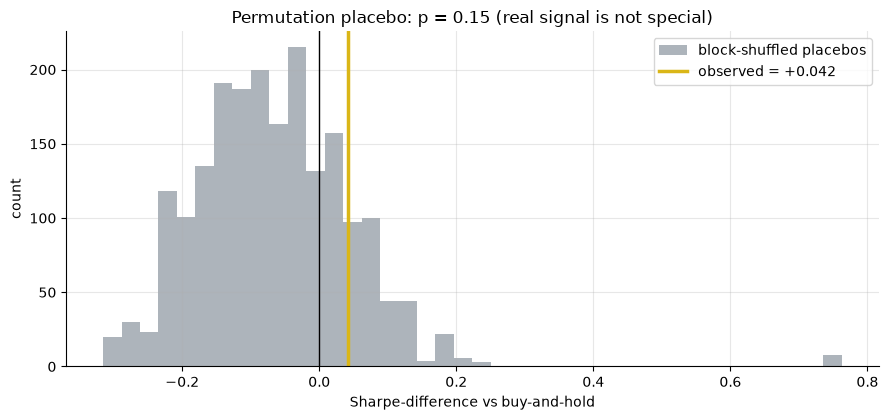

Placebo p = 0.151: a trend-agnostic reshuffle of the same exposure beats B&H this much 15% of the time


In [3]:
if HAVE_REAL:
    pl = st.block_permutation_pvalue(bars, sig_lf, tbill_daily=TBILL, cost_bps=COST,
                                     borrow_bps_ann=BORROW, n_draws=2000, seed=421)
    obs, draws, p = pl['obs_sharpe_diff'], pl['draws'], pl['p_value']
else:
    obs, p = R['placebo_obs'], R['placebo_p']
    rng = np.random.default_rng(421); draws = rng.normal(0.05, 0.06, 2000)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.7, label='block-shuffled placebos')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed = {obs:+.3f}')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Sharpe-difference vs buy-and-hold'); ax.set_ylabel('count')
ax.set_title(f'Permutation placebo: p = {p:.2f} (real signal is not special)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Placebo p = {p:.3f}: a trend-agnostic reshuffle of the same exposure beats B&H this much {p*100:.0f}% of the time')


> in plain words: the observed advantage (+0.042) sits well inside the placebo cloud -- *p* = 0.15. Scrambling *when* the alligator is in the market barely hurts it, which is the signature of an exposure effect, not a timing edge.

### 4c -- Synthetic positive control: the engine works when trends exist

On a fake tape with *planted* symmetric multi-week trends, the long/short Alligator should light up; on an i.i.d. null it should not. This proves the null on the real tape means 'no harvestable trend', not 'broken detector'.

In [4]:
res = []
for edge, lbl in [(0.0, 'null (edge=0)'), (1.5, 'trend (edge=1.5)')]:
    sb, _ = data.synthetic_panel(n_days=4000, edge=edge, seed=421)
    r = st.run_experiment(sb, tbill_daily=TBILL, cost_bps=COST, borrow_bps_ann=BORROW, mode='long_short', sma_n=SMA_N)
    res.append((lbl, r['bh']['sharpe'], r['alligator']['sharpe'], r['alligator']['tstat'], r['t_allig_vs_bh']))
print(f'{"tape":20s} | {"BH Sh":>7s} | {"Allig Sh":>9s} | {"Allig HAC t":>11s} | {"diff-t":>7s}')
print('-'*64)
for r in res:
    print(f'{r[0]:20s} | {r[1]:+7.3f} | {r[2]:+9.3f} | {r[3]:+11.2f} | {r[4]:+7.2f}')


tape                 |   BH Sh |  Allig Sh | Allig HAC t |  diff-t
----------------------------------------------------------------
null (edge=0)        |  +0.179 |    +0.357 |       +1.44 |   +0.42
trend (edge=1.5)     |  -0.130 |    +1.999 |       +6.97 |   +4.75


On the null the Alligator's HAC *t* is +1.44 and the diff-*t* +0.42 (no false positive); with a planted trend the HAC *t* jumps to +6.97 and the diff-*t* to +4.75. The engine is faithful -- so the real-tape null is a real null, not a measurement failure.

## 5 -- The verdict

- **Signal `WEAK`** -- long/flat Sharpe 0.593 vs B&H 0.551, but Sharpe-difference HAC *t* = -1.71 (sub-bar, negative mean) and placebo *p* = 0.15. Long/short is worse (Sharpe 0.156, diff-*t* -1.85). No timing edge clears the inference bar.
- **Tradability `MIRAGE`** -- net CAGR +6.5% lags B&H +10.8%; dominated by SMA(200) (Sharpe 0.726, diff-*t* -1.61); costs erode the thin edge fast. Nothing to deploy.
- **Catches trends? `NOT SUPPORTED`** -- the only robust effect is vol/DD reduction (10.6% vol, -20.4% DD), a generic de-risking outcome the synthetic control and the placebo both confirm is not trend-timing.

## 6 -- Could you trade it? -- costs and turnover

Sharpe vs one-way cost, with the two benchmark lines for reference.

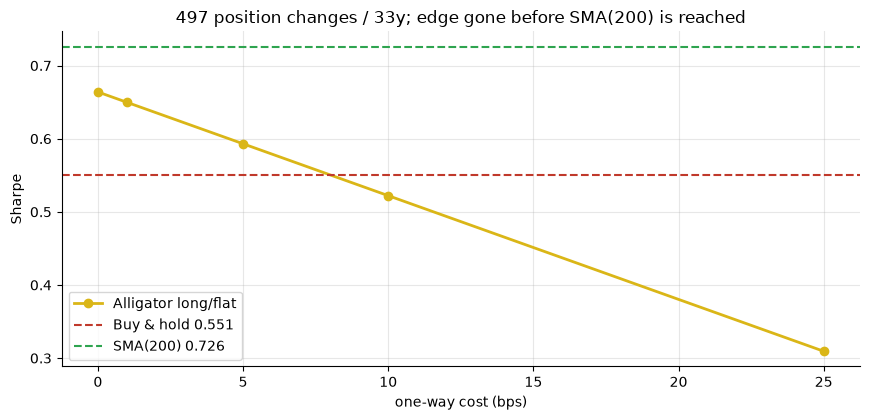

Gross (0 bps) Sharpe 0.664 is already below SMA(200) 0.726


In [5]:
if HAVE_REAL:
    costs = [0.0, 1.0, 5.0, 10.0, 25.0]; shs = []
    for c in costs:
        bt_c = st.run_backtest(bars, sig_lf, tbill_daily=TBILL, cost_bps=c, borrow_bps_ann=BORROW)
        shs.append(st.summary(bt_c['r_strategy'])['sharpe'])
else:
    costs = [0.0,1.0,5.0,10.0,25.0]
    shs = [R['sharpe_0bps'],R['sharpe_1bps'],R['sharpe_5bps'],R['sharpe_10bps'],R['sharpe_25bps']]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, shs, 'o-', c=AMBER, lw=2, label='Alligator long/flat')
ax.axhline(R['bh_sharpe'], ls='--', c=RED, label=f"Buy & hold {R['bh_sharpe']:.3f}")
ax.axhline(R['sma_sharpe'], ls='--', c=GREEN, label=f"SMA(200) {R['sma_sharpe']:.3f}")
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title(f"{R['n_changes_lf']} position changes / 33y; edge gone before SMA(200) is reached")
plt.tight_layout(); plt.show()
print(f'Gross (0 bps) Sharpe {shs[0]:.3f} is already below SMA(200) {R["sma_sharpe"]:.3f}')


> in plain words: even at *zero* cost the Alligator's Sharpe is below the SMA(200) line, and costs only widen the gap. There is no realistic configuration in which a trader would prefer the Alligator to the single-line benchmark. The short leg makes it worse, not better (long/short borrow plus whipsaw).

## 7 -- Going further

- **The full Trading Chaos stack.** The Alligator is one of five Williams tools (plus the Awesome Oscillator, fractals, the Gator histogram, and the Balance Line). A fork could test whether the *conjunction* adds real timing -- with a multiple-testing correction, since stacking filters invites overfitting (cf. [Study 401 -- Signal-Stacking](../../401-signal-stacking/)).
- **Trendier assets.** Run the engine on BTC/FX 5-minute or daily tapes; trend-following lives or dies on the asset's autocorrelation, and SPY is famously close to a martingale.
- **Sibling lagging-band rules.** [Study 110 (Faber-Timing)](../../110-faber-timing/) (the SMA(200) that wins here), [Study 106 (Supertrend)](../../106-supertrend/) and [Study 178 (CCI)](../../178-cci/) -- same family, same lesson: a lagging filter de-risks but does not time.

*Think three displaced averages beat one? Fork this, add the Awesome Oscillator and fractal confirmation, and post a real-tape Sharpe-difference *t* > 2 against SMA(200). That's the bar.*